In [1]:
from src.data.bayesian_b_updater import BayesianGRBUpdater
import src
from src.data.preparation import prepare_data_tpp
from config.config_loader import load_args_from_yaml 
import pandas as pd
from pathlib import Path
from  src.train.config_setup import load_and_prepare_model
import torch
import matplotlib.pyplot as plt
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Loading  the checkpoint

In [2]:
checkpoint_dir = Path("../checkpoints/mixer_tpp_20260116-153148") 
checkpoint_path = checkpoint_dir / "last_model_1.pth"

In [3]:
args= load_args_from_yaml(checkpoint_dir / "config.yaml")
args.use_b_updater = False
base_dir = f"../data/{args.dataset}"
seq, train_loader, val_loader, test_loader, catalog_ds = prepare_data_tpp(base_dir=base_dir, args=args,)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/ChuanDian/raw.
Number of training events: 4498
Number of validation events: 567


In [4]:
ts_start = catalog_ds.metadata['start_ts']

In [5]:
args.b_updater_cfg

{'delta': 0.98, 'a0': 50, 'init_b_target': 1}

In [6]:
catalog_ds.metadata['mag_completeness']

3.0

## Using Bayesian GR b Updater

In [7]:
updater = BayesianGRBUpdater(Mc=catalog_ds.metadata['mag_completeness'], delta=0.98, a0=50, init_b_target=1, mag_key="mag", write_back=True)
results = updater.fit(seq,prefix="bayes_")          

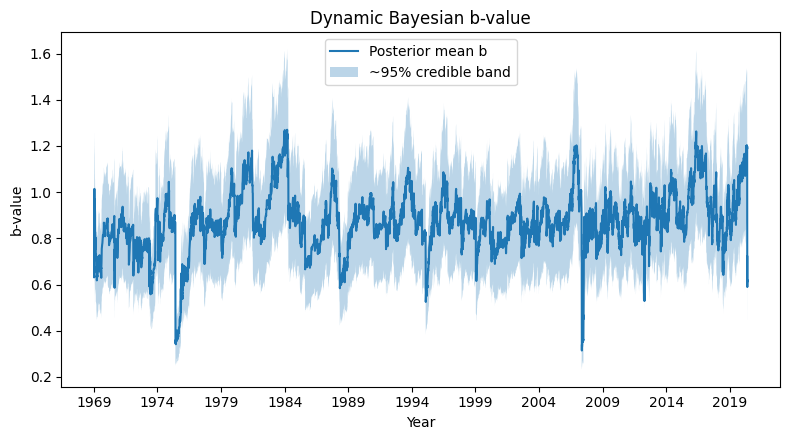

In [8]:
BayesianGRBUpdater.plot(seq, x_axis="time", time_key="arrival_times",prefix="bayes_",start_time=ts_start)    

## Using Fixed Window GR b Updater

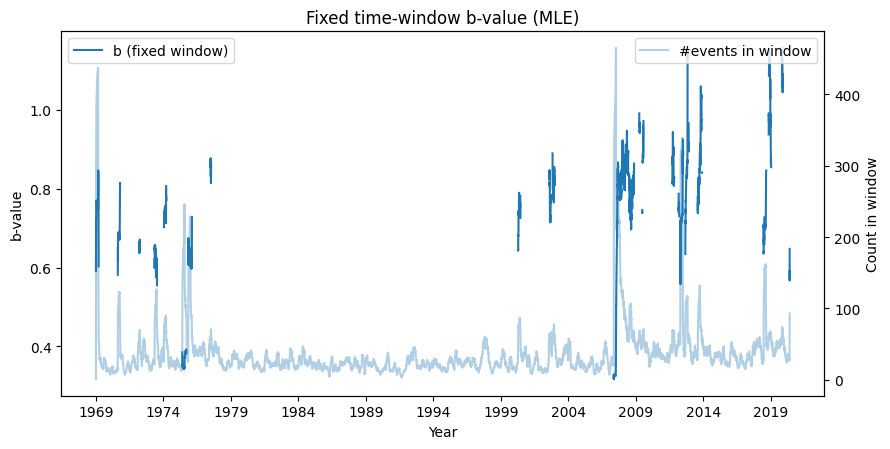

In [9]:
from src.data.slidewindow_b_updater import FixedTimeWindowGRB
est = FixedTimeWindowGRB(Mc=catalog_ds.metadata['mag_completeness'], window_len=60.0, min_count=60,
                         mag_key="mag", time_key="arrival_times",
                         method="mle")   
est.fit(seq,prefix="fixed_")
FixedTimeWindowGRB.plot(seq, x_axis="time", show_counts=True,prefix="fixed_",start_time=ts_start)


# est_auto = FixedTimeWindowGRB(Mc=catalog_ds.metadata['mag_completeness'], target_count=100, min_count=50,
#                               mag_key="mag", time_key="arrival_times",
#                               method="mle")
# est_auto.fit(seq,prefix="fixed_")
# FixedTimeWindowGRB.plot(seq, x_axis="time", show_counts=False,prefix="fixed_")


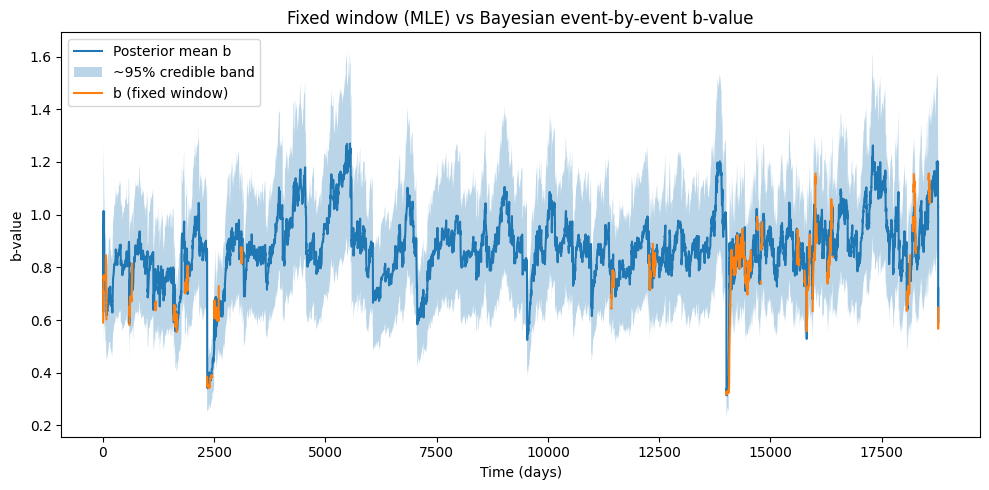

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
BayesianGRBUpdater.plot(seq,
                        x_axis="time",
                        time_key="arrival_times",
                        ax=ax,
                        title="",            
                        prefix="bayes_",
                        show=False)
FixedTimeWindowGRB.plot(seq,
                        x_axis="time",
                        show_counts=False,  
                        ax=ax,
                        title="",          
                        prefix="fixed_",
                        show=False)
ax.set_title("Fixed window (MLE) vs Bayesian event-by-event b-value")
ax.legend(loc="best")

plt.tight_layout()
plt.show()

## Loading model to predict GR-b

In [11]:
model, args = load_and_prepare_model(checkpoint_path,device=device)

using time scale base 1.6484907865524292 (key: tau_mean)
tau mean: 1.6484907865524292
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'mixer_tpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'hf_cosine', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'dropout': 0.3, 'd_model': 64, 'mixer_model_config': {'input_dim': 1, 'dropout_prob': 0.1, 'd_model': 64, 'n_layer': 2, 'd_intermediate': 128, 'attn_layer_idx': [], 'ssm_cfg': {'layer': 'Mamba2Rotary', 'use_conv': False, 'rotary_emb_scale_base': 2048}, 'attn_cfg': {'layer': 'MHATime', 'num_heads': 4, 'rotary_emb_dim': 8, 'rotary_emb_scale_base': 2048, 'causal': True}, 'norm_epsilon': 1e-05, 'rms_norm': False, 'initializer_cfg':

In [12]:
from scipy.ndimage import gaussian_filter1d
from  src.utils.utils import _to_np_datetime64_seconds, _to_py_datetime,set_xaxis_time_locator
import matplotlib.dates as mdates

def plot_b_value(
    seq,
    b_seq: torch.Tensor,
    x_axis: str = "time",          # "time" or "event"
    time_key: str = "arrival_times",
    title: str = "",
    label: str = "b-value",
    fig: plt.Figure = None,
    ax: plt.Axes = None,
    show: bool = True,
    smooth: bool = False,         
    smooth_sigma: float = 1.0,      # Standard deviation for Gaussian smoothing (applies to Gaussian filter)
    start_time: pd.Timestamp = None, 
):
    if isinstance(b_seq, torch.Tensor):
        b_seq = b_seq.squeeze().detach().cpu().numpy()

    if smooth:
        b_seq = gaussian_filter1d(b_seq, sigma=smooth_sigma)
      
    if x_axis == "time":
        if time_key not in seq:
            raise KeyError(f"Sequence is missing the time field '{time_key}'")
        days = seq[time_key].detach().cpu().numpy() 

        if start_time is None:
            xs = days
            xlabel = "Time (days)"
        else:
            t0_np = _to_np_datetime64_seconds(start_time)
            xs = t0_np + days.astype('timedelta64[D]')  # Convert to calendar dates
            xlabel = "Year"
    elif x_axis == "event":
        xs = range(len(b_seq))
        xlabel = "Event index"
    else:
        raise ValueError("x_axis must be 'time' or 'event'")

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(xs, b_seq, label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("b-value")
    ax.set_title(title)
    ax.legend(loc="best")
    ax.grid(alpha=0.3)

    plt.tight_layout()

    if x_axis == "time" and start_time is not None:
        set_xaxis_time_locator(ax, start_time)
    if show:
        plt.show()
    return fig, ax


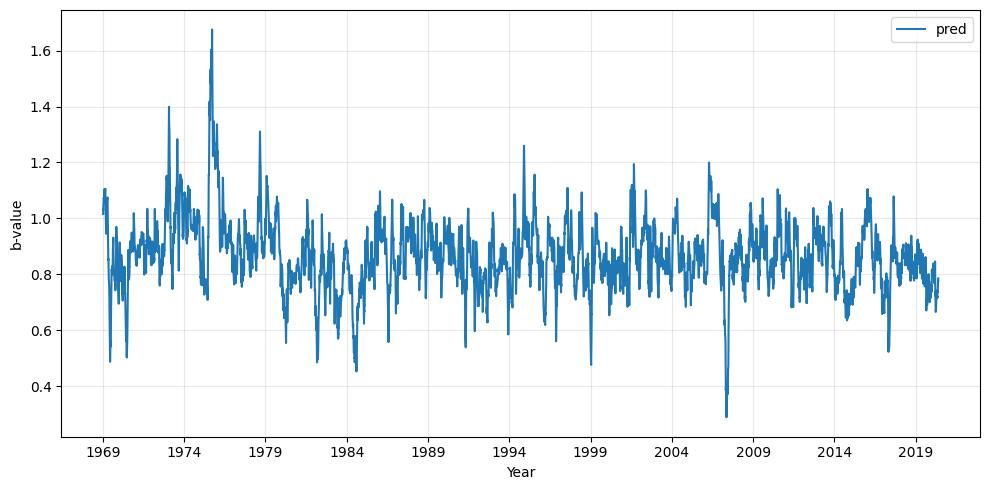

(<Figure size 1000x500 with 1 Axes>, <Axes: xlabel='Year', ylabel='b-value'>)

In [13]:
b_pred = model.compute_b_value(seq.to(device), True)[:, :-1]
plot_b_value(seq, b_pred, label="pred",smooth=False,start_time=ts_start)

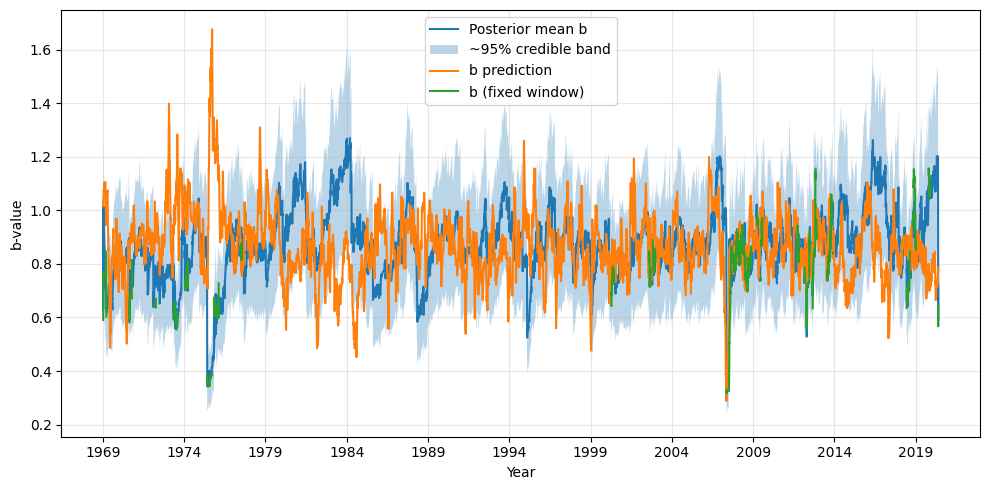

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
BayesianGRBUpdater.plot(seq,
                        x_axis="time",
                        time_key="arrival_times",
                        ax=ax,
                        title="",            
                        prefix="bayes_",
                        show=False,
                        start_time=ts_start)

plot_b_value(seq, b_pred, label="b prediction",smooth=False,fig=fig,ax=ax,show=False,start_time=ts_start)
FixedTimeWindowGRB.plot(seq,
                        x_axis="time",
                        show_counts=False,  
                        ax=ax,
                        title="",          
                        prefix="fixed_",
                        show=False,
                        start_time=ts_start)
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(checkpoint_dir/"b_result.pdf", bbox_inches="tight")  
plt.show()


In [15]:
checkpoint_dir

PosixPath('../checkpoints/mixer_tpp_20260116-153148')